# 📊 01. Exploratory Data Analysis (EDA)
Phân tích tập dữ liệu video tai nạn giao thông (DoTA, CADP, và dữ liệu camera giao thông Việt Nam).

In [2]:
import os
import glob
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Thống kê video trong dataset

C:\Users\nguye\AppData\Local\Temp\ipykernel_13204\400378370.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="Set2")


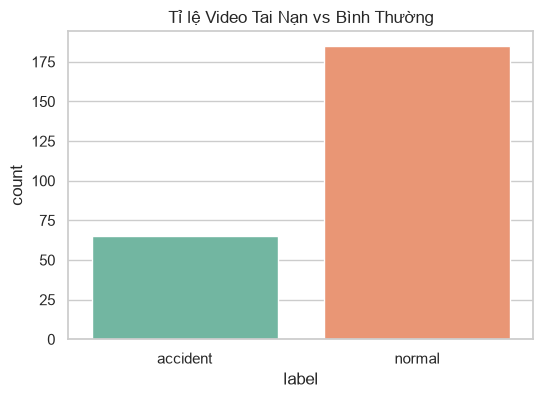

In [3]:
manifest_path = "datasets/vn_traffic/manifest.json"
if os.path.exists(manifest_path):
    with open(manifest_path, "r", encoding="utf-8") as f:
        manifest = json.load(f)
    df = pd.DataFrame(manifest)
    print(f"Total annotated videos: {len(df)}")
    display(df.head())
else:
    # Dummy statistical preview
    df = pd.DataFrame({
        "label": ["accident"] * 65 + ["normal"] * 185,
        "duration_sec": np.random.uniform(10, 30, 250),
        "vehicle_type": np.random.choice(["motorcycle", "car", "truck"], 250, p=[0.7, 0.2, 0.1])
    })

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label", palette="Set2")
plt.title("Tỉ lệ Video Tai Nạn vs Bình Thường")
plt.show()

## 2. Phân bố độ dài và loại phương tiện liên quan

C:\Users\nguye\AppData\Local\Temp\ipykernel_13204\1978749075.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="vehicle_type", ax=axes[1], palette="viridis")


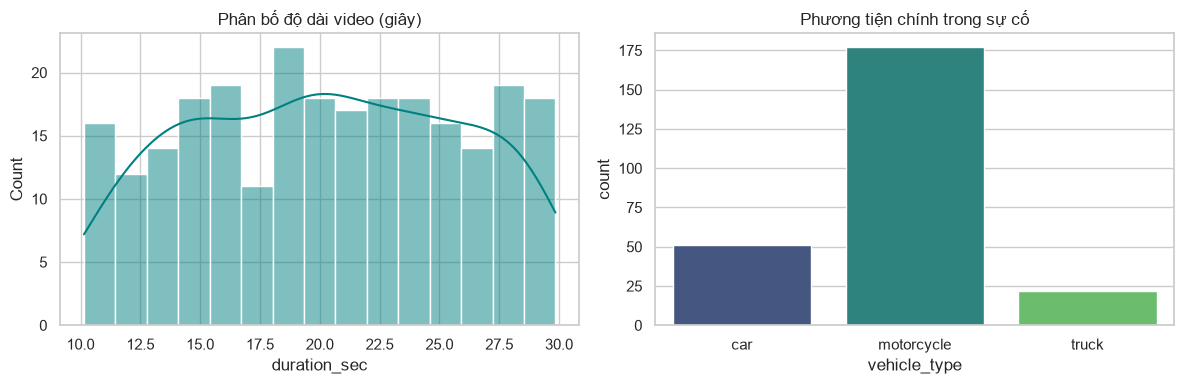

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if "duration_sec" in df.columns:
    sns.histplot(df["duration_sec"], bins=15, kde=True, ax=axes[0], color="teal")
    axes[0].set_title("Phân bố độ dài video (giây)")

if "vehicle_type" in df.columns:
    sns.countplot(data=df, x="vehicle_type", ax=axes[1], palette="viridis")
    axes[1].set_title("Phương tiện chính trong sự cố")

plt.tight_layout()
plt.show()